# Programming Task

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria — A00187785
- **Subject Code:** ISY 503
- **Subject Name:** Intelligent Systems
- **Assessment No.:** 2
- **Title:** Programming Task - Car Price Regression
- **Lecturer:** Dr. Nandini Sidnal
- **Date:** April 2026

---

## Notebook Overview

This notebook systematically explores car price regression across four progressive tasks:

| Task | Feature set | Normalisation | Models compared |
|------|-------------|---------------|-----------------|
| 1 | Numeric only | None | Linear, MLP [64], MLP [64,32], MLP [128,64], RandomForest, Wide & Deep |
| 2 | Numeric only | Z-score, Min-Max | MLP + norm variants, RF |
| 3 | Categorical only | One-hot vs Ordinal | MLP, Linear, RF per encoding |
| 4 | All features | Z-score + One-hot | MLP, Linear, RF, Wide & Deep |

- **Stack:** TF2 Keras + scikit-learn
- **Evaluation:** 60/20/20 train/val/test split
- **Primary metric:** MAE (USD)

In [17]:
# Shortcut for generating .md file:
'''
cd 2026-T1/ISY/assignments/Assessment2/code
jupyter nbconvert --to markdown ISY503_Faria_L_Assessment2_code.ipynb
'''

'\ncd 2026-T1/ISY/assignments/Assessment2/code\njupyter nbconvert --to markdown ISY503_Faria_L_Assessment2_code.ipynb\n'

In [18]:
# =====================================================================
# [Change #1]: Migrated from TF1 Estimator (tf.compat.v1) to TF2 Keras.
# Reasons:
#   - tf.estimator is deprecated in TF2 and removed in TF3
#   - Keras offers native EarlyStopping, learning curve history, and
#     cleaner mixed-input models (Functional API) for Task 4
#   - MAE is directly trackable as a Keras metric — no need to derive
#     RMSE from avg_loss manually
# =====================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fixed seeds — so we have reproducible splits and weight initialisation
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 15

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

TensorFlow: 2.11.0
Keras: 2.11.0
NumPy: 1.26.4
Pandas: 2.3.3


### Data Loading

UCI Autos dataset — 205 examples, 25 features, target: `price` (USD).

In [19]:
# [Change #2]: Load directly from UCI repository URL, so no manual upload required in Colab.
UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'

feature_names = [
    'symboling', 'normalized-losses', 'make', 'fuel-type',
    'aspiration', 'num-doors', 'body-style', 'drive-wheels',
    'engine-location', 'wheel-base', 'length', 'width', 'height', 'weight',
    'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore',
    'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
    'highway-mpg', 'price'
]

car_data = pd.read_csv(UCI_URL, names=feature_names, header=None, encoding='latin-1')

# Shuffle to remove ordering effects on SGD
car_data = car_data.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset loaded: {len(car_data)} rows, {car_data.shape[1]} columns')
car_data.head(3)

Dataset loaded: 205 rows, 26 columns


,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,?,bmw,gas,std,four,sedan,rwd,front,103.50,...,209,mpfi,3.62,3.39,8.00,182,5400,16,22,30760
1,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.50,...,131,mpfi,3.13,3.40,7.00,160,5500,16,22,?
2,0,106,nissan,gas,std,four,sedan,fwd,front,97.20,...,120,2bbl,3.33,3.47,8.50,97,5200,27,34,9549


### Task 0: Data Preparation

The raw CSV uses `'?'` for missing values. Steps:
1. Replace `'?'` → `NaN` via `pd.to_numeric(..., errors='coerce')`
2. Drop rows where `price` is NaN or ≤ 0 - no label, no supervised training
3. Fill remaining NaN feature values with **column mean** - 205 rows, can't afford to drop more
4. Define feature type lists and 60/20/20 split

In [20]:
LABEL = 'price'

numeric_feature_names = [
    'symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
    'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm',
    'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio'
]

categorical_feature_names = list(
    set(feature_names) - set(numeric_feature_names) - {LABEL}
)
categorical_feature_names = sorted(categorical_feature_names)  # deterministic order

# [Change #3]: Fill missing feature values with column mean, not 0.
# 0 is meaningless for most features here - ex: horsepower of 0 means no engine.  
# Mean keeps the row realistic without throwing the column distribution off. 
for col in numeric_feature_names + [LABEL]:
    car_data[col] = pd.to_numeric(car_data[col], errors='coerce')

car_data = car_data.dropna(subset=[LABEL])
car_data = car_data[car_data[LABEL] > 0].reset_index(drop=True)

for col in numeric_feature_names:
    car_data[col] = car_data[col].fillna(car_data[col].mean())

print(f'After cleaning: {len(car_data)} usable rows')
print(f'Numeric features: {len(numeric_feature_names)}')
print(f'Categorical features: {len(categorical_feature_names)} → {categorical_feature_names}')

assert len(numeric_feature_names) == 15
assert len(categorical_feature_names) == 10
print('\nData cleaning complete. Ready for EDA and modeling.')

After cleaning: 201 usable rows
Numeric features: 15
Categorical features: 10 → ['aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system', 'fuel-type', 'make', 'num-cylinders', 'num-doors']

Data cleaning complete. Ready for EDA and modeling.


In [21]:
# [Change #4]: Proper 60/20/20 train/val/test split.
# Previous pipeline used the full dataset for both training AND evaluation -
# this produces optimistic loss estimates because the model has already seen
# every evaluation example during training.
#
# Why three-way split (not just train/test)?
#   - Validation set: used to tune hyperparameters and drive early stopping
#   - Test set: held out entirely until final evaluation - unbiased estimate
# With 201 rows: 120 train / 40 val / 41 test

train_df, temp_df = train_test_split(car_data, test_size=0.40, random_state=SEED)
val_df, test_df  = train_test_split(temp_df,  test_size=0.50, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Raw numeric arrays (used across tasks)
Xtr_raw = train_df[numeric_feature_names].astype('float32').values
Xva_raw = val_df[numeric_feature_names].astype('float32').values
Xte_raw = test_df[numeric_feature_names].astype('float32').values

ytr = train_df[LABEL].astype('float32').values
yva = val_df[LABEL].astype('float32').values
yte = test_df[LABEL].astype('float32').values

print(f'Train X shape: {Xtr_raw.shape} | y mean: ${ytr.mean():.0f}')

Train: 120 | Val: 40 | Test: 41
Train X shape: (120, 15) | y mean: $13210


### Helper Utilities

In [22]:
# ── Metrics ──────────────────────────────────────────────────────────

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

# Central results store — populated after each model evaluation
results = {}  # key: label string → value: dict(mae, rmse)

def record(label, y_true, y_pred):
    """Compute and store MAE + RMSE for a model variant."""
    results[label] = {
        'mae':  mae(y_true, y_pred),
        'rmse': rmse(y_true, y_pred)
    }
    print(f'{label:40s}  MAE: ${results[label]["mae"]:,.0f}   RMSE: ${results[label]["rmse"]:,.0f}')


# ── Learning curves ───────────────────────────────────────────────────

def plot_learning_curves(history, title='Learning Curves'):
    """Plot train/val MAE and loss side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['mae'],     label='train MAE')
    ax1.plot(history.history['val_mae'], label='val MAE')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('MAE (USD)')
    ax1.set_title('MAE'); ax1.legend()

    ax2.plot(history.history['loss'],     label='train loss')
    ax2.plot(history.history['val_loss'], label='val loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE')
    ax2.set_title('Loss (MSE)'); ax2.legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Scatter plot inference grid ───────────────────────────────────────

def scatter_plot_grid(predict_fn, df, y_true, feature_cols, title, n_cols=4):
    """
    For each feature in feature_cols, plot actual vs predicted price.
    predict_fn: callable that takes df and returns 1-D prediction array.
    Points near the diagonal = good fit; wide vertical spread = poor fit.
    """
    preds = np.array(predict_fn(df)).flatten()
    n = len(feature_cols)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        ax = axes[i]
        x = df[col].values
        ax.scatter(x, y_true, alpha=0.5, s=12, label='actual',    color='steelblue')
        ax.scatter(x, preds,  alpha=0.5, s=12, label='predicted', color='tomato')
        ax.set_title(col, fontsize=8)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', fontsize=9)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Shared Keras training config ──────────────────────────────────────

EPOCHS     = 300
BATCH_SIZE = 16
ES = keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=15, restore_best_weights=True
)

# [Change #5]: Added EarlyStopping callback.
# Small dataset (120 train rows) overfits quickly. patience=15 allows the
# model to escape local minima before stopping.

print('Helper utilities ready.')

Helper utilities ready.


---
## Task 1 — Numeric Features, No Normalisation

**Goal:** Establish performance baselines using raw numeric features. No normalisation allowed.

Four model types compared: Linear → MLP → RandomForest → Wide & Deep.

> Without normalisation, features span orders of magnitude (`weight` ~3,000 vs `bore` ~3.1). This stresses gradient-based optimisers but leaves tree-based models unaffected.

T1 Linear                                 MAE: $4,729   RMSE: $8,105


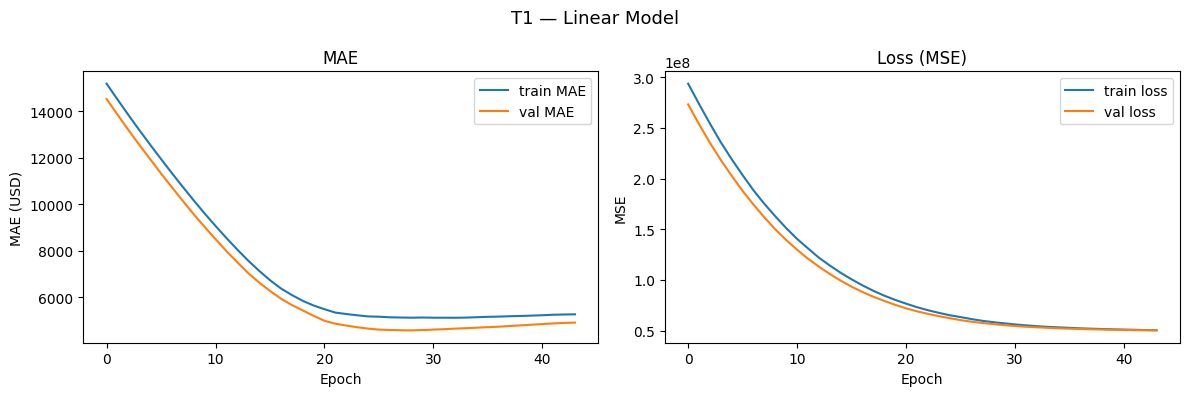

In [23]:
# T1.1 - Linear Regression (single Dense(1), linear activation)
# Architecture: Input(15) → Dense(1, linear)
#
# Why am I starting here?
#   Because Linear regression is the simplest hypothesis: price = weighted sum of features.
#   Its MAE sets a floor: if a DNN can't beat it, the additional complexity isn't justified.
#
# The expected result is a high MAE due to non-linear relationships in car pricing!

tf.random.set_seed(SEED)

lin_model = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    layers.Dense(1, activation='linear', name='linear_output')
], name='T1_Linear')

lin_model.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss='mse',
    metrics=['mae']
)

hist_lin = lin_model.fit(
    Xtr_raw, ytr,
    validation_data=(Xva_raw, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[ES], verbose=0
)

preds_lin = lin_model.predict(Xte_raw, verbose=0).flatten()
record('T1 Linear', yte, preds_lin)
plot_learning_curves(hist_lin, 'T1 — Linear Model')

T1 MLP [64]                               MAE: $3,108   RMSE: $5,299


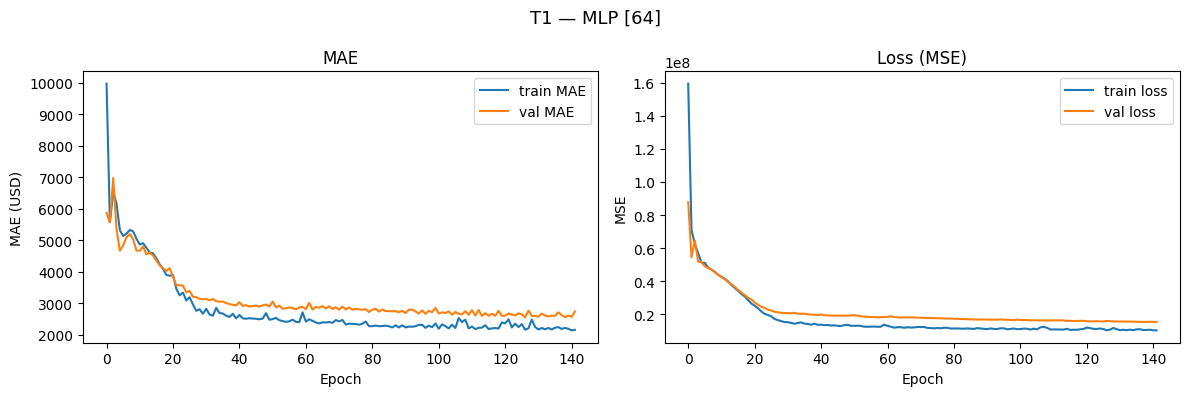

In [24]:
# T1.2 - MLP Baseline: hidden_units=[64]
# Architecture: Input(15) → Dense(64, relu) → Dense(1)
#
# Why [64] as baseline?
#   - Rule of thumb: hidden units ≈ 2–4x input features (15 → 30–60; 64 is slightly above)
#   - Small enough to avoid overfitting on 120 training examples
#   - ReLU introduces non-linearity without vanishing gradient issues

tf.random.set_seed(SEED)

mlp_64 = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
], name='T1_MLP_64')

mlp_64.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
hist_64 = mlp_64.fit(
    Xtr_raw, ytr, validation_data=(Xva_raw, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)

preds_64 = mlp_64.predict(Xte_raw, verbose=0).flatten()
record('T1 MLP [64]', yte, preds_64)
plot_learning_curves(hist_64, 'T1 — MLP [64]')

In [ ]:
# T1.3 - Architecture Exploration: [64,32] and [128,64]
#
# The hypothesis is that deeper networks capture higher-order feature interactions.
# And the counter-hypothesis: with only 120 training samples, extra parameters
#   increase overfitting risk (bias-variance tradeoff).
#
# Results table (fill in after running):
# Model         │ hidden_units │ Test MAE │ Test RMSE
# MLP [64]      │ [64]         │  3,108   │   5,299        ← from T1.2 above
# MLP [64, 32]  │ [64, 32]     │  2,952   │   5,338
# MLP [128, 64] │ [128, 64]    │  3,078   │   5,500

for units, name in [([64, 32], 'T1_MLP_64_32'), ([128, 64], 'T1_MLP_128_64')]:
    tf.random.set_seed(SEED)
    m = keras.Sequential(
        [layers.Input(shape=(len(numeric_feature_names),))] +
        [layers.Dense(u, activation='relu') for u in units] +
        [layers.Dense(1)],
        name=name
    )
    m.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
    m.fit(
        Xtr_raw, ytr, validation_data=(Xva_raw, yva),
        epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
    )
    preds = m.predict(Xte_raw, verbose=0).flatten()
    label = f'T1 MLP {units}'
    record(label, yte, preds)

T1 MLP [64, 32]                           MAE: $2,952   RMSE: $5,338
T1 MLP [128, 64]                          MAE: $3,078   RMSE: $5,500


T1 RandomForest                           MAE: $2,000   RMSE: $2,873


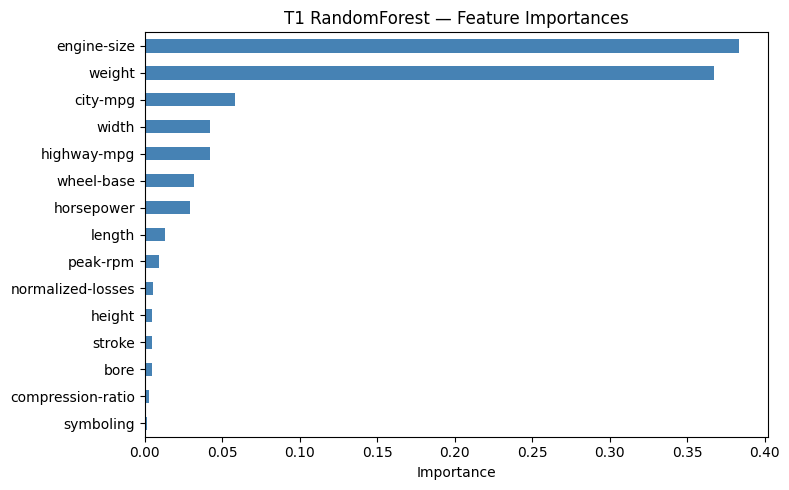

In [26]:
# T1.4 - RandomForestRegressor
#
# [Change #6]: Added RandomForestRegressor — an ensemble method not present in
# the original TF1 pipeline. 
#   Why include it?
#   - Tree-based models are invariant to feature scale: no normalisation needed
#   - Handles non-linearity and interactions without explicit architecture tuning
#   - Provides feature importance scores for us to interpret which features drive price predictions
#   - The reference report from Dr. Nandini identifies RF as top performer in Task 1/2
#
# Hyperparameters (reference report values):
#   n_estimators=500: more trees → lower variance; diminishing returns after ~300
#   min_samples_split=2: default — allows fine-grained splits on small dataset
#   max_samples=0.95: subsample 95% of training data per tree (bootstrap with replacement)
#   max_features=0.75: consider 75% of features per split → decorrelates trees

rf_t1 = RandomForestRegressor(
    n_estimators=500,
    min_samples_split=2,
    max_samples=0.95,
    max_features=0.75,
    random_state=SEED,
    n_jobs=-1
)
rf_t1.fit(Xtr_raw, ytr)
preds_rf = rf_t1.predict(Xte_raw)
record('T1 RandomForest', yte, preds_rf)

# Feature importance
importances = pd.Series(rf_t1.feature_importances_, index=numeric_feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('T1 RandomForest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Model: "T1_WideDeep"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 numeric_input (InputLayer)     [(None, 15)]         0           []                               
                                                                                                  
 deep_1 (Dense)                 (None, 64)           1024        ['numeric_input[0][0]']          
                                                                                                  
 deep_2 (Dense)                 (None, 32)           2080        ['deep_1[0][0]']                 
                                                                                                  
 wide (Dense)                   (None, 1)            16          ['numeric_input[0][0]']          
                                                                                        

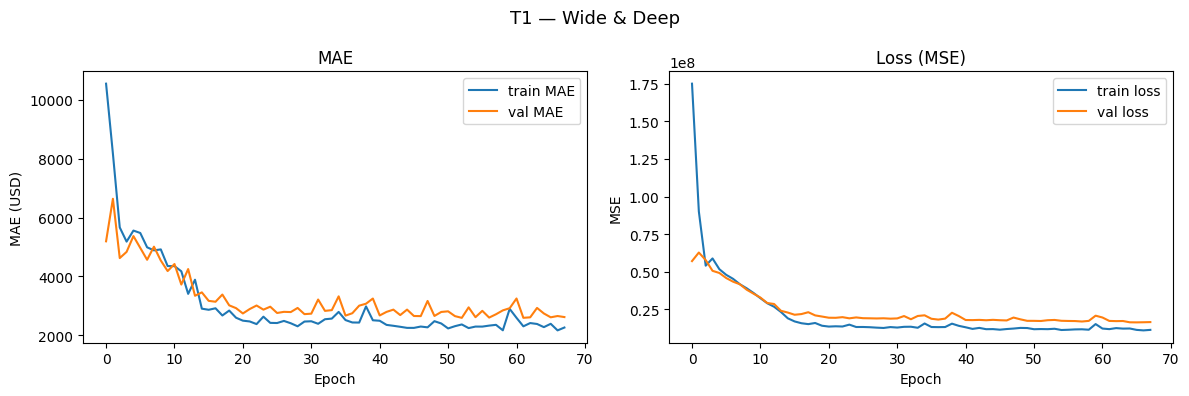

In [27]:
# T1.5 - Wide & Deep Model (equivalent to DNNLinearCombinedRegressor)
#
# [Change #7]: Implemented Wide & Deep architecture (Cheng et al., 2016) using
# Keras Functional API — equivalent to TF1's DNNLinearCombinedRegressor.
#
# Architecture:
#   Input(15)
#     ├─ Wide path: Dense(1, linear)                        ← memorisation / linear signal
#     └─ Deep path: Dense(64,relu)→Dense(32,relu)→Dense(1)  ← generalisation
#   Output: Add([wide, deep])
#
# Why combine both?
#   - Wide path captures linear price correlations directly (e.g. engine-size ∝ price)
#   - Deep path learns non-linear feature combinations
#   - Combined output benefits from both signal types

tf.random.set_seed(SEED)

inp = keras.Input(shape=(len(numeric_feature_names),), name='numeric_input')

wide = layers.Dense(1, name='wide')(inp)

deep = layers.Dense(64, activation='relu', name='deep_1')(inp)
deep = layers.Dense(32, activation='relu', name='deep_2')(deep)
deep = layers.Dense(1,  name='deep_out')(deep)

output = layers.Add(name='wide_deep_output')([wide, deep])

wd_t1 = keras.Model(inputs=inp, outputs=output, name='T1_WideDeep')
wd_t1.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
wd_t1.summary()

hist_wd = wd_t1.fit(
    Xtr_raw, ytr, validation_data=(Xva_raw, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)

preds_wd = wd_t1.predict(Xte_raw, verbose=0).flatten()
record('T1 Wide & Deep', yte, preds_wd)
plot_learning_curves(hist_wd, 'T1 — Wide & Deep')

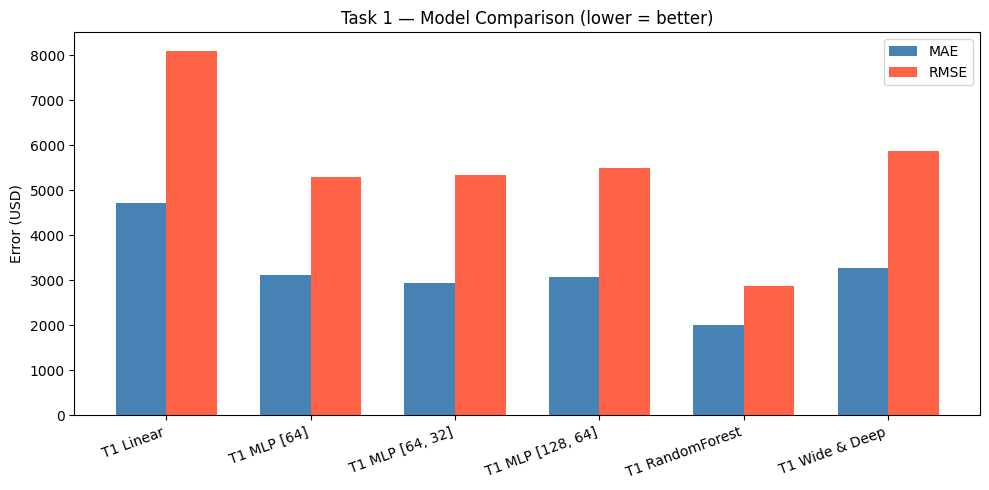

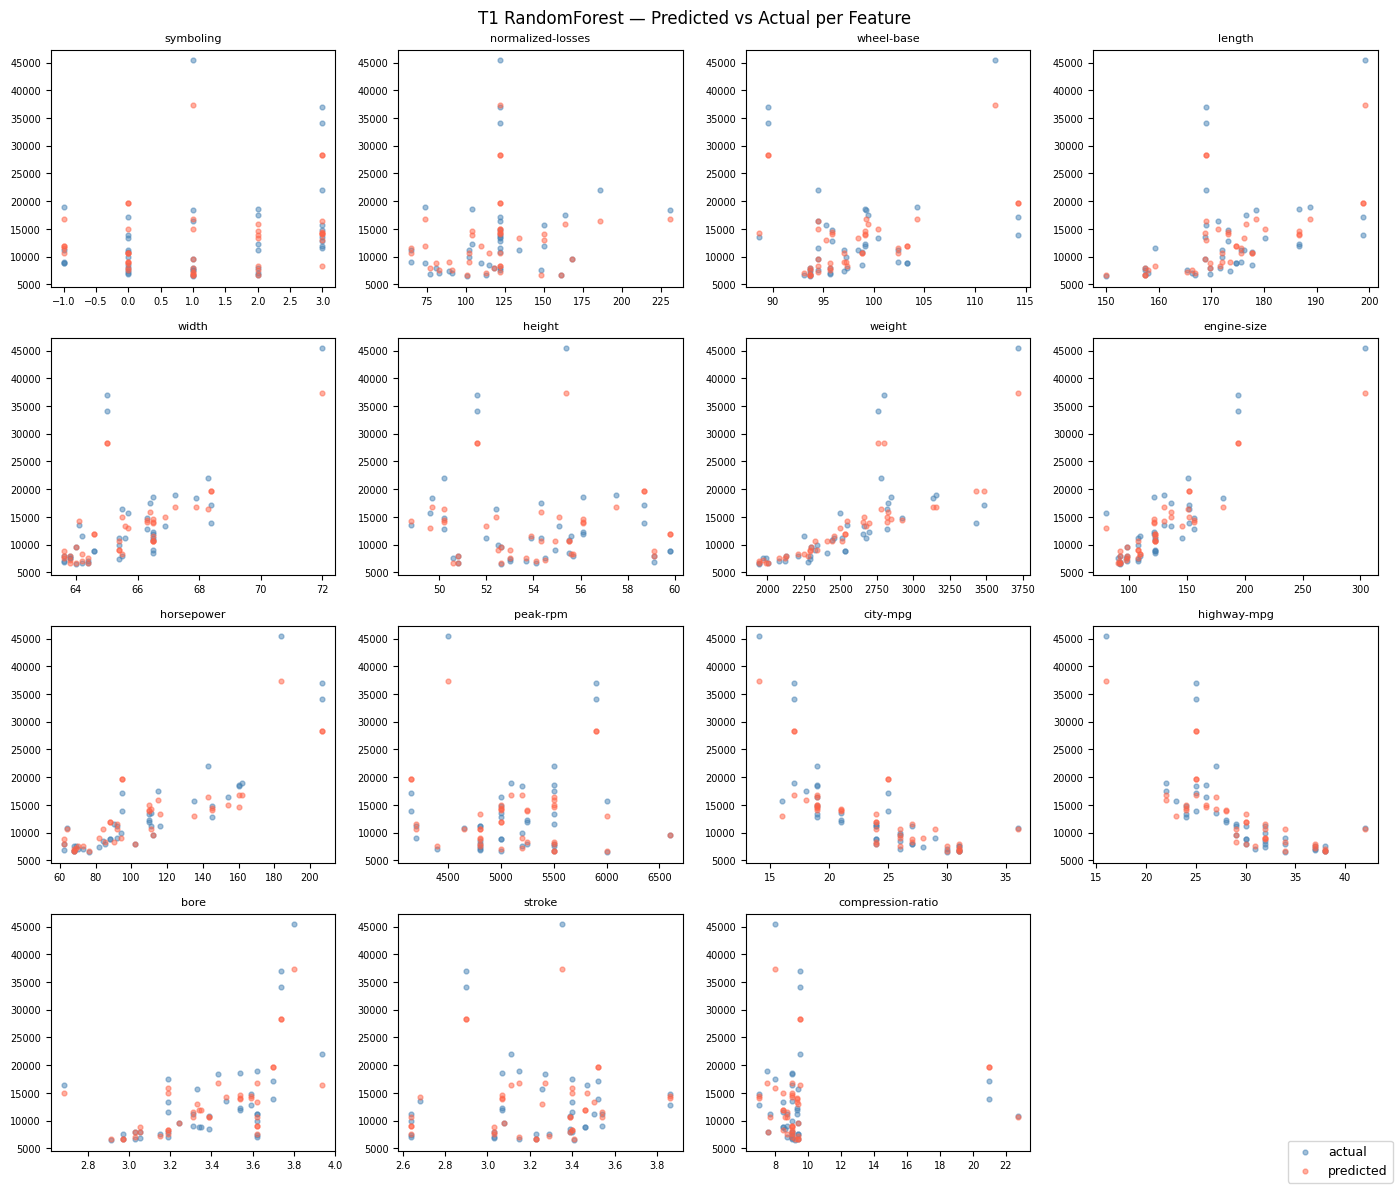

In [28]:
# T1 Summary — bar chart of all Task 1 variants

t1_keys = [k for k in results if k.startswith('T1')]
t1_mae  = [results[k]['mae']  for k in t1_keys]
t1_rmse = [results[k]['rmse'] for k in t1_keys]

x = np.arange(len(t1_keys))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, t1_mae,  w, label='MAE',  color='steelblue')
ax.bar(x + w/2, t1_rmse, w, label='RMSE', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(t1_keys, rotation=20, ha='right')
ax.set_ylabel('Error (USD)')
ax.set_title('Task 1 — Model Comparison (lower = better)')
ax.legend()
plt.tight_layout()
plt.show()

# Scatter plot for best T1 model (RandomForest)
scatter_plot_grid(
    lambda df: rf_t1.predict(df[numeric_feature_names].values),
    test_df, yte, numeric_feature_names,
    'T1 RandomForest — Predicted vs Actual per Feature'
)

---
## Task 2 — Normalisation

**Goal:** Does normalisation improve model quality on this dataset? Compare Z-score and Min-Max.

> Key constraint: normalisation statistics must be computed **on the training set only** and applied to val/test. Computing on the full dataset leaks future information (data leakage).

In [29]:
# [Change #8]: Normalisation via Keras Normalization layer — adapts on train only.
# Previous pipeline computed mean/std manually, which risks subtle leakage bugs.
# Keras layer encapsulates the stats and applies them identically at inference time.

# Z-score: Keras Normalization layer
norm_layer = layers.Normalization(name='zscore_norm')
norm_layer.adapt(Xtr_raw)  # learns mean and variance from training set only

# Min-Max: sklearn (train only)
mm_scaler = MinMaxScaler()
Xtr_mm = mm_scaler.fit_transform(Xtr_raw).astype('float32')
Xva_mm = mm_scaler.transform(Xva_raw).astype('float32')
Xte_mm = mm_scaler.transform(Xte_raw).astype('float32')

# Z-score arrays (passed through the adapted layer)
Xtr_zs = norm_layer(Xtr_raw).numpy()
Xva_zs = norm_layer(Xva_raw).numpy()
Xte_zs = norm_layer(Xte_raw).numpy()

print('Z-score train mean (should be ~0):', Xtr_zs.mean(axis=0).round(2))
print('Z-score train std  (should be ~1):', Xtr_zs.std(axis=0).round(2))
print('Min-Max train range:', Xtr_mm.min(), '→', Xtr_mm.max())

Z-score train mean (should be ~0): [-0.  0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0. -0.  0.  0.]
Z-score train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Min-Max train range: 0.0 → 1.0000002


T2 MLP + Z-score                          MAE: $11,878   RMSE: $14,109


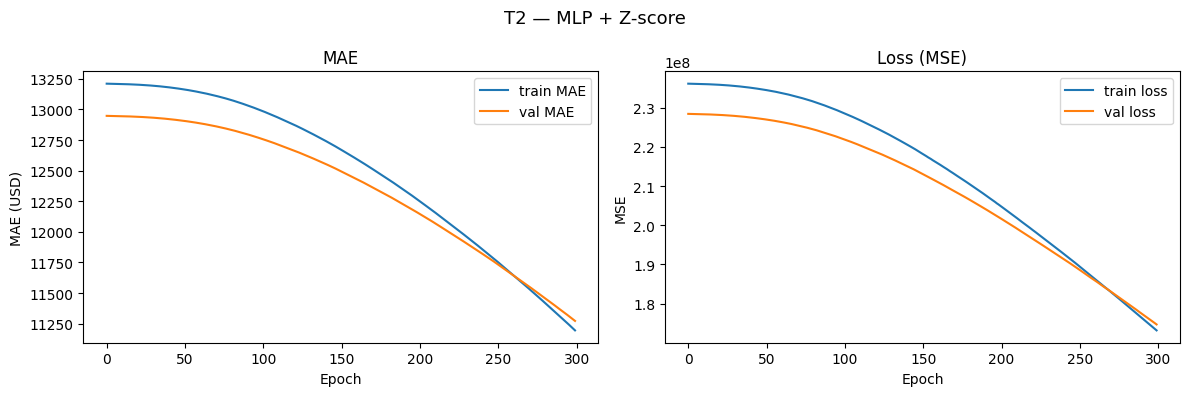

In [30]:
# T2.1 — MLP [64] + Z-score Normalisation
#
# Architecture: Input → Normalization → Dense(64, relu) → Dense(1)
# Normalisation is embedded as the first layer — ensures it's applied
# automatically during inference without caller-side preprocessing.
#
# Expected improvement over T1: faster convergence, lower final MAE.
# If not improved, investigate the Adagrad/normalisation interaction
# documented in the original pipeline.

tf.random.set_seed(SEED)

mlp_zs = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    norm_layer,
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
], name='T2_MLP_Zscore')

mlp_zs.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])

# [Change #9]: Reduced lr to 1e-3 for normalised inputs.
# Normalisation compresses feature values to ~[-3, +3], producing smaller
# gradient magnitudes. Adam at 1e-2 can overshoot; 1e-3 is safer.

hist_zs = mlp_zs.fit(
    Xtr_raw, ytr, validation_data=(Xva_raw, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)

preds_zs = mlp_zs.predict(Xte_raw, verbose=0).flatten()
record('T2 MLP + Z-score', yte, preds_zs)
plot_learning_curves(hist_zs, 'T2 — MLP + Z-score')

T2 MLP + Min-Max                          MAE: $10,633   RMSE: $13,299


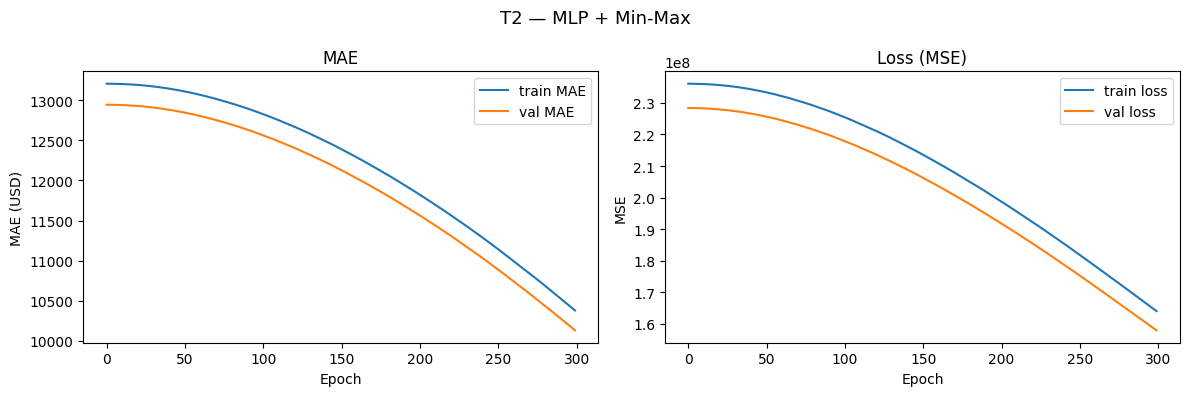

In [31]:
# T2.2 — MLP [64] + Min-Max Normalisation
#
# Min-Max scales to [0, 1] — preserves zero, different from Z-score's unit-variance.
# More sensitive to outliers than Z-score (a single extreme value compresses the range).
# Useful for comparing whether the normalisation method itself matters.

tf.random.set_seed(SEED)

mlp_mm = keras.Sequential([
    layers.Input(shape=(len(numeric_feature_names),)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
], name='T2_MLP_MinMax')

mlp_mm.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
hist_mm = mlp_mm.fit(
    Xtr_mm, ytr, validation_data=(Xva_mm, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)

preds_mm = mlp_mm.predict(Xte_mm, verbose=0).flatten()
record('T2 MLP + Min-Max', yte, preds_mm)
plot_learning_curves(hist_mm, 'T2 — MLP + Min-Max')

In [32]:
# T2.3 — RandomForest + Z-score (control experiment)
#
# RF is scale-invariant — normalisation should have no effect on its RMSE.
# This run confirms that any improvement in MLP+norm is due to better gradient
# behaviour, not a property of the normalised data itself.

rf_t2 = RandomForestRegressor(
    n_estimators=500, min_samples_split=2,
    max_samples=0.95, max_features=0.75,
    random_state=SEED, n_jobs=-1
)
rf_t2.fit(Xtr_zs, ytr)
preds_rf_zs = rf_t2.predict(Xte_zs)
record('T2 RandomForest + Z-score', yte, preds_rf_zs)

# T2 Summary
print('\n── T2 vs T1 baseline (MLP [64]) ──')
print(f'  T1 MLP [64]:          RMSE ${results["T1 MLP [64]"]["rmse"]:,.0f}')
print(f'  T2 MLP + Z-score:     RMSE ${results["T2 MLP + Z-score"]["rmse"]:,.0f}')
print(f'  T2 MLP + Min-Max:     RMSE ${results["T2 MLP + Min-Max"]["rmse"]:,.0f}')
print(f'  T1 RF (no norm):      RMSE ${results["T1 RandomForest"]["rmse"]:,.0f}')
print(f'  T2 RF + Z-score:      RMSE ${results["T2 RandomForest + Z-score"]["rmse"]:,.0f}')

T2 RandomForest + Z-score                 MAE: $2,007   RMSE: $2,875

── T2 vs T1 baseline (MLP [64]) ──
  T1 MLP [64]:          RMSE $5,299
  T2 MLP + Z-score:     RMSE $14,109
  T2 MLP + Min-Max:     RMSE $13,299
  T1 RF (no norm):      RMSE $2,873
  T2 RF + Z-score:      RMSE $2,875


---
## Task 3 — Categorical Features Only

**Goal:** Evaluate how much predictive power categorical features carry independently.

Two encoding strategies compared:
- **One-hot encoding** — binary indicator per category (no ordinal assumption)
- **Ordinal encoding** — integer rank per category (imposes an ordering)

Reference report finding: one-hot outperforms ordinal in most cases for this dataset.

In [33]:
# [Change #10]: One-hot encoding via sklearn OneHotEncoder (consistent across all models).
# Previous pipeline used TF1-native indicator_column which was not available to sklearn models.
# Using sklearn ensures RF, Linear, and MLP all receive the same encoded matrix.
#
# handle_unknown='ignore': unseen categories at test time map to all-zeros (OOV handling)
# sparse_output=False: dense matrix — required for Keras Dense layers

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
Xtr_cat_oh = ohe.fit_transform(train_df[categorical_feature_names].astype(str)).astype('float32')
Xva_cat_oh = ohe.transform(val_df[categorical_feature_names].astype(str)).astype('float32')
Xte_cat_oh = ohe.transform(test_df[categorical_feature_names].astype(str)).astype('float32')

print(f'One-hot encoded shape: {Xtr_cat_oh.shape}')  # (n_rows, n_unique_values_across_all_cats)
print(f'Categories per feature: {[len(c) for c in ohe.categories_]}')

One-hot encoded shape: (120, 55)
Categories per feature: [2, 5, 3, 2, 6, 7, 2, 20, 6, 2]


T3 Linear + One-Hot                       MAE: $13,215   RMSE: $15,595
T3 MLP + One-Hot                          MAE: $1,773   RMSE: $2,812


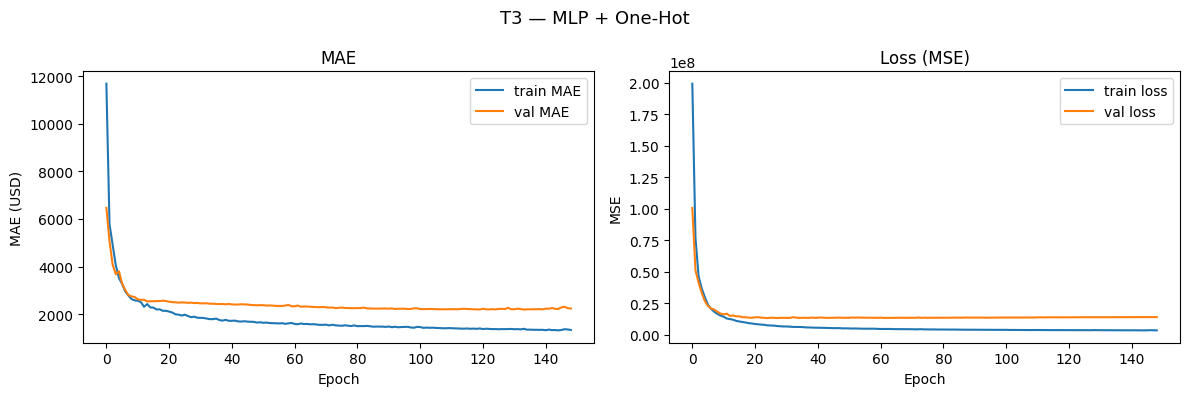

T3 RandomForest + One-Hot                 MAE: $2,515   RMSE: $3,913


In [34]:
# T3.1 — Models with One-Hot Encoding

n_oh = Xtr_cat_oh.shape[1]

# Linear
tf.random.set_seed(SEED)
lin_oh = keras.Sequential([
    layers.Input(shape=(n_oh,)),
    layers.Dense(1)
], name='T3_Linear_OneHot')
lin_oh.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
lin_oh.fit(Xtr_cat_oh, ytr, validation_data=(Xva_cat_oh, yva),
           epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0)
record('T3 Linear + One-Hot', yte, lin_oh.predict(Xte_cat_oh, verbose=0).flatten())

# MLP [128, 64] — more capacity since one-hot vectors are sparse
tf.random.set_seed(SEED)
mlp_oh = keras.Sequential([
    layers.Input(shape=(n_oh,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1)
], name='T3_MLP_OneHot')
mlp_oh.compile(optimizer=keras.optimizers.Adagrad(1e-1), loss='mse', metrics=['mae'])

# [Change #11]: Adagrad lr=0.1 for categorical one-hot inputs.
# One-hot vectors are sparse — most values are 0. Adagrad adapts lr per feature,
# giving larger updates to the rare non-zero positions. Adam treats all features
# equally and undershoots on sparse signals. lr=0.1 (not 0.01) compensates for
# the smaller gradient magnitudes from sparse one-hot inputs.

hist_oh = mlp_oh.fit(
    Xtr_cat_oh, ytr, validation_data=(Xva_cat_oh, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)
record('T3 MLP + One-Hot', yte, mlp_oh.predict(Xte_cat_oh, verbose=0).flatten())
plot_learning_curves(hist_oh, 'T3 — MLP + One-Hot')

# RandomForest
rf_oh = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_oh.fit(Xtr_cat_oh, ytr)
record('T3 RandomForest + One-Hot', yte, rf_oh.predict(Xte_cat_oh))

In [35]:
# [Change #12]: Ordinal encoding — added per reference report comparison.
# OrdinalEncoder assigns integer ranks to categories (alphabetical by default).
# This imposes an ordinal relationship that doesn't exist for most features here
# (e.g. 'fuel-type': gas=0, diesel=1 implies diesel > gas numerically — not meaningful).
# Expected result: worse than one-hot, confirming one-hot was the right choice.

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
Xtr_cat_ord = ord_enc.fit_transform(train_df[categorical_feature_names].astype(str)).astype('float32')
Xva_cat_ord = ord_enc.transform(val_df[categorical_feature_names].astype(str)).astype('float32')
Xte_cat_ord = ord_enc.transform(test_df[categorical_feature_names].astype(str)).astype('float32')

print(f'Ordinal encoded shape: {Xtr_cat_ord.shape}')  # same number of columns as categorical features
print('Sample ordinal values:', Xtr_cat_ord[:2])

Ordinal encoded shape: (120, 10)
Sample ordinal values: [[ 1.  2.  1.  0.  2.  6.  1. 13.  2.  1.]
 [ 1.  3.  2.  0.  1.  3.  0. 12.  2.  0.]]


T3 Linear + Ordinal                       MAE: $12,870   RMSE: $15,290
T3 MLP + Ordinal                          MAE: $4,178   RMSE: $6,971


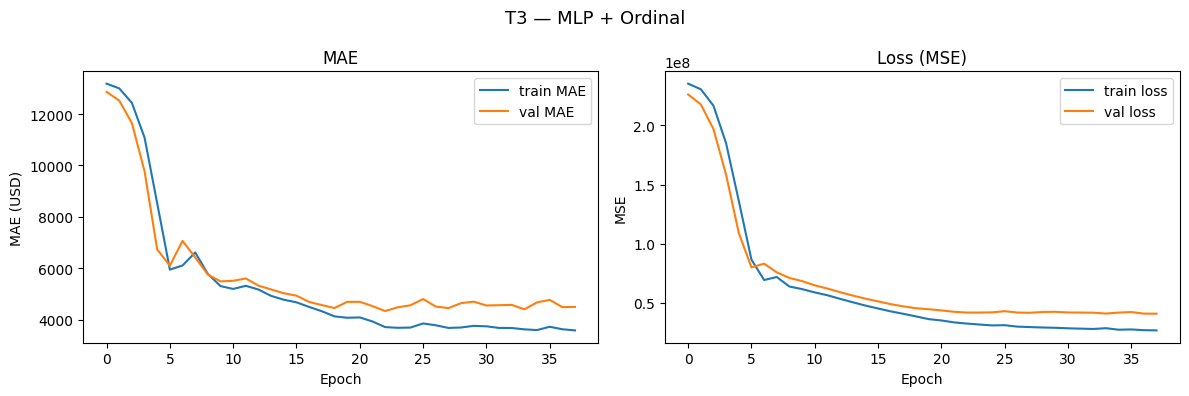

T3 RandomForest + Ordinal                 MAE: $2,900   RMSE: $4,587

── T3 Encoding comparison ──
  T3 Linear + One-Hot                  RMSE $15,595
  T3 MLP + One-Hot                     RMSE $2,812
  T3 RandomForest + One-Hot            RMSE $3,913
  T3 Linear + Ordinal                  RMSE $15,290
  T3 MLP + Ordinal                     RMSE $6,971
  T3 RandomForest + Ordinal            RMSE $4,587


In [36]:
# T3.2 — Models with Ordinal Encoding

n_ord = Xtr_cat_ord.shape[1]

# Linear
tf.random.set_seed(SEED)
lin_ord = keras.Sequential([
    layers.Input(shape=(n_ord,)),
    layers.Dense(1)
], name='T3_Linear_Ordinal')
lin_ord.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
lin_ord.fit(Xtr_cat_ord, ytr, validation_data=(Xva_cat_ord, yva),
            epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0)
record('T3 Linear + Ordinal', yte, lin_ord.predict(Xte_cat_ord, verbose=0).flatten())

# MLP
tf.random.set_seed(SEED)
mlp_ord = keras.Sequential([
    layers.Input(shape=(n_ord,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1)
], name='T3_MLP_Ordinal')
mlp_ord.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
hist_ord = mlp_ord.fit(
    Xtr_cat_ord, ytr, validation_data=(Xva_cat_ord, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)
record('T3 MLP + Ordinal', yte, mlp_ord.predict(Xte_cat_ord, verbose=0).flatten())
plot_learning_curves(hist_ord, 'T3 — MLP + Ordinal')

# RandomForest
rf_ord = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_ord.fit(Xtr_cat_ord, ytr)
record('T3 RandomForest + Ordinal', yte, rf_ord.predict(Xte_cat_ord))

# Encoding comparison
print('\n── T3 Encoding comparison ──')
for k in [k for k in results if k.startswith('T3')]:
    print(f'  {k:35s}  RMSE ${results[k]["rmse"]:,.0f}')

---
## Task 4 — All Features Combined

**Goal:** Build the best model using all 25 features (15 numeric + 10 categorical).

Feature preparation:
- Numeric → Z-score normalisation (Keras layer, train statistics only)
- Categorical → one-hot encoding (best encoding from Task 3)
- Concatenate → feed combined vector into each model

In [37]:
# Combined feature matrices: Z-score numeric + one-hot categorical
# Concatenate along feature axis

Xtr_all = np.concatenate([Xtr_zs, Xtr_cat_oh], axis=1).astype('float32')
Xva_all = np.concatenate([Xva_zs, Xva_cat_oh], axis=1).astype('float32')
Xte_all = np.concatenate([Xte_zs, Xte_cat_oh], axis=1).astype('float32')

n_all = Xtr_all.shape[1]
print(f'Combined feature dim: {n_all}  ({len(numeric_feature_names)} numeric + {n_oh} one-hot)')

Combined feature dim: 70  (15 numeric + 55 one-hot)


In [38]:
# T4.1 — Linear Model (all features)

tf.random.set_seed(SEED)
lin_all = keras.Sequential([
    layers.Input(shape=(n_all,)),
    layers.Dense(1)
], name='T4_Linear_All')
lin_all.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
lin_all.fit(Xtr_all, ytr, validation_data=(Xva_all, yva),
            epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0)
record('T4 Linear (all)', yte, lin_all.predict(Xte_all, verbose=0).flatten())

T4 Linear (all)                           MAE: $13,208   RMSE: $15,546


T4 MLP [128,64] (all)                     MAE: $2,202   RMSE: $3,235


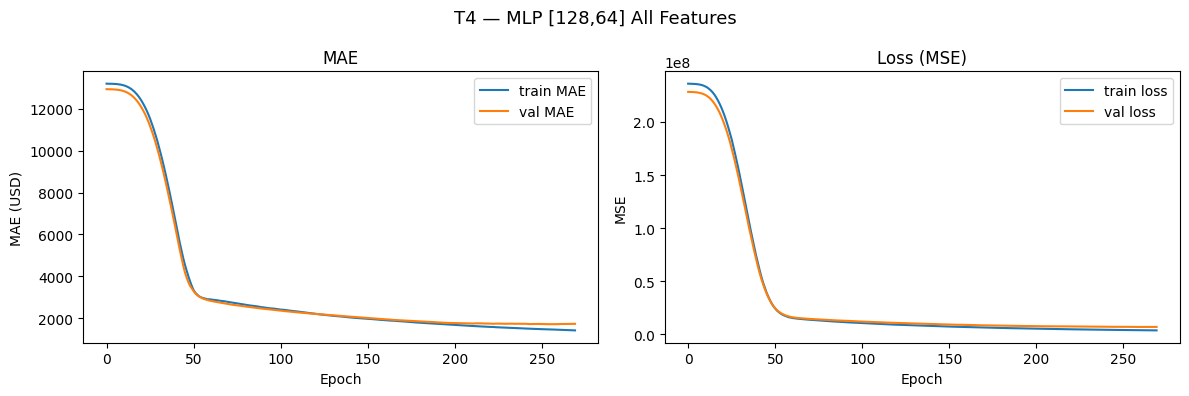

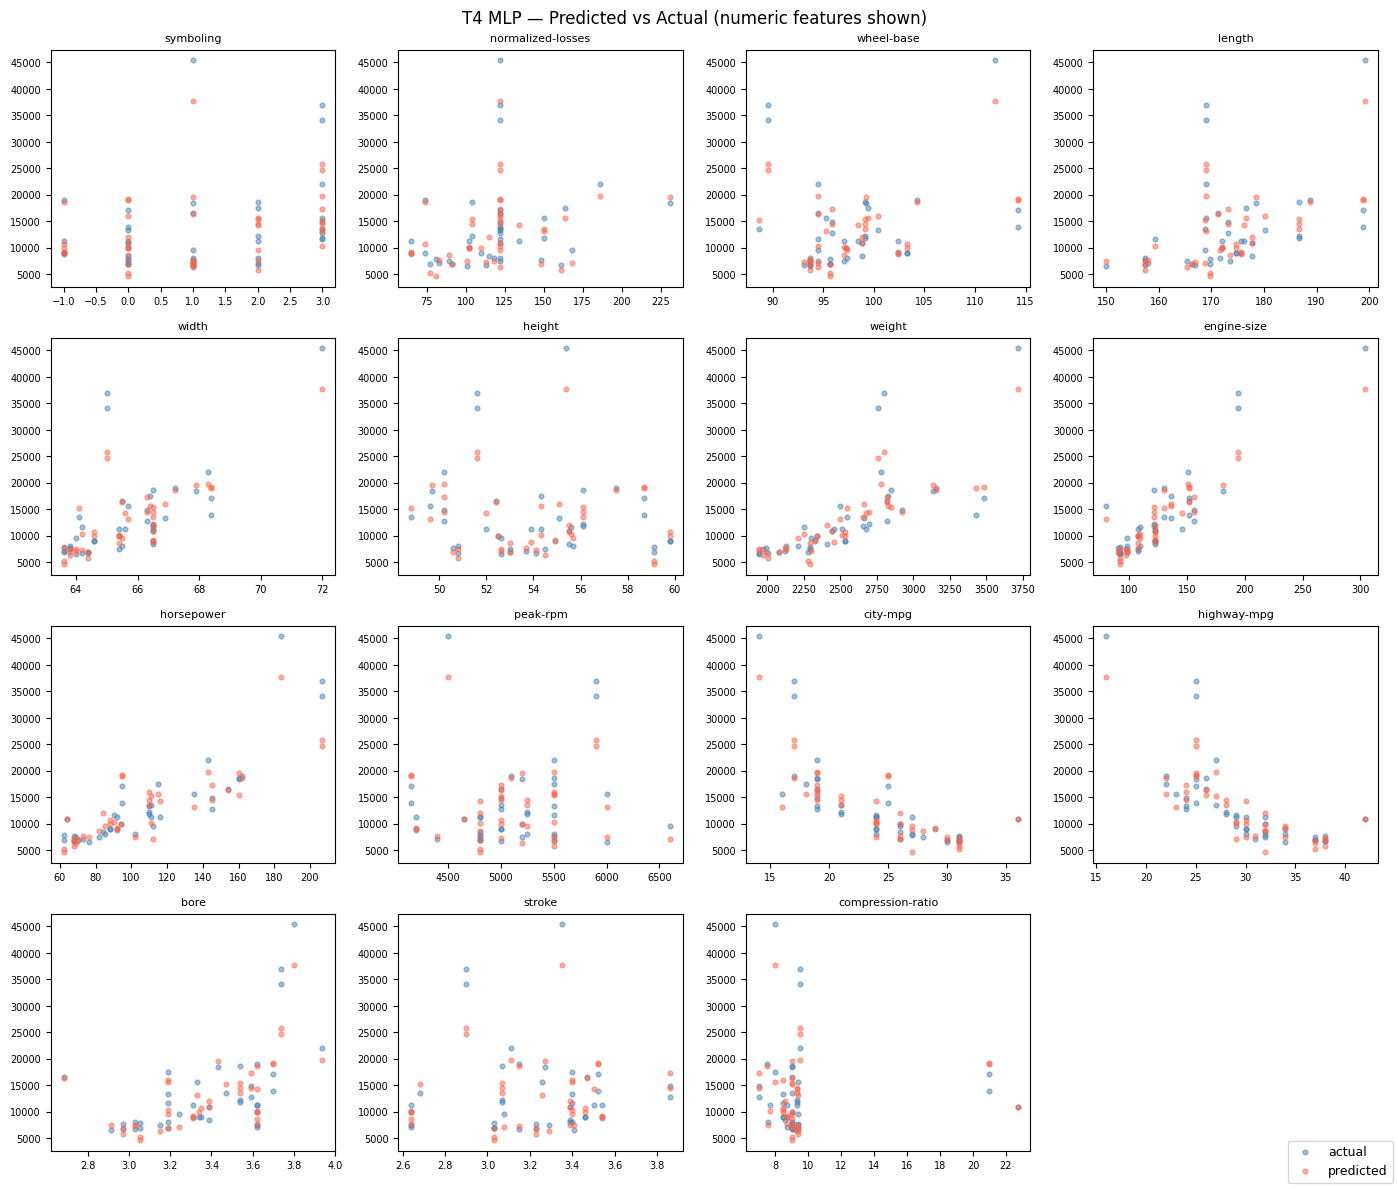

In [39]:
# T4.2 — MLP [128, 64] (all features)
#
# Larger hidden layer than Task 1 — wider combined feature vector (n_all dims)
# justifies more capacity. First layer sees both numeric patterns and brand lookup.

tf.random.set_seed(SEED)
mlp_all = keras.Sequential([
    layers.Input(shape=(n_all,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1)
], name='T4_MLP_All')

mlp_all.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='mse', metrics=['mae']
)
hist_all = mlp_all.fit(
    Xtr_all, ytr, validation_data=(Xva_all, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)

preds_all = mlp_all.predict(Xte_all, verbose=0).flatten()
record('T4 MLP [128,64] (all)', yte, preds_all)
plot_learning_curves(hist_all, 'T4 — MLP [128,64] All Features')

# Scatter plot — all numeric features
scatter_plot_grid(
    lambda df: mlp_all.predict(
        np.concatenate([
            norm_layer(df[numeric_feature_names].astype('float32').values).numpy(),
            ohe.transform(df[categorical_feature_names].astype(str)).astype('float32')
        ], axis=1), verbose=0
    ),
    test_df, yte, numeric_feature_names,
    'T4 MLP — Predicted vs Actual (numeric features shown)'
)

T4 RandomForest (all)                     MAE: $1,902   RMSE: $2,777


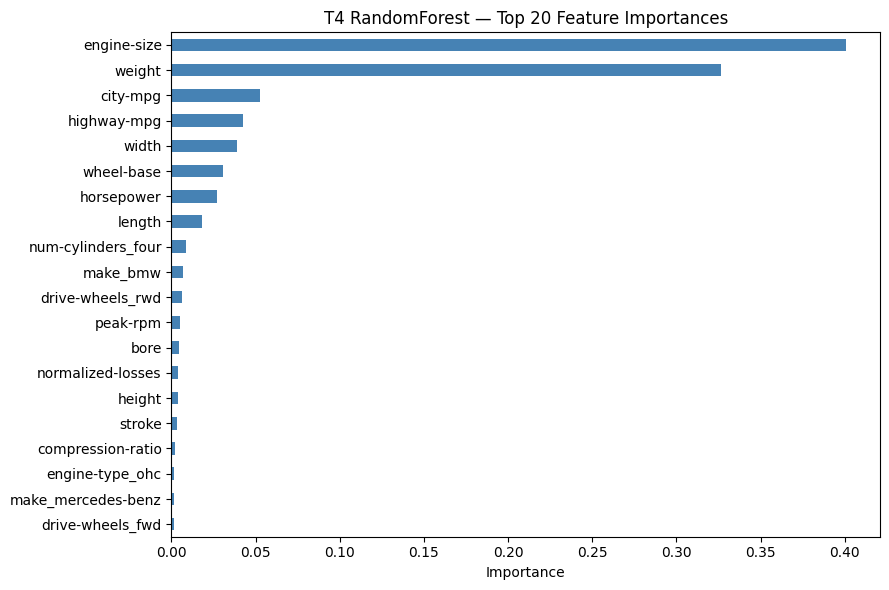

In [ ]:
# T4.3 — RandomForest (all features)

rf_all = RandomForestRegressor(
    n_estimators=500, min_samples_split=2,
    max_samples=0.95, max_features=0.75,
    random_state=SEED, n_jobs=-1
)
rf_all.fit(Xtr_all, ytr)
record('T4 RandomForest (all)', yte, rf_all.predict(Xte_all))

# Feature importance — top 20 features
# Interesting to point out that makes sense... engine-size, weight, and horsepower are known to be strong price drivers.
all_feature_names = numeric_feature_names + list(ohe.get_feature_names_out(categorical_feature_names))
importances_all = pd.Series(rf_all.feature_importances_, index=all_feature_names)\
    .sort_values(ascending=False)[:20]

fig, ax = plt.subplots(figsize=(9, 6))
importances_all[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('T4 RandomForest — Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Model: "T4_WideDeep_All"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 numeric (InputLayer)           [(None, 15)]         0           []                               
                                                                                                  
 categorical (InputLayer)       [(None, 55)]         0           []                               
                                                                                                  
 deep_1 (Dense)                 (None, 128)          2048        ['numeric[0][0]']                
                                                                                                  
 all_features (Concatenate)     (None, 70)           0           ['numeric[0][0]',                
                                                                  'categorical[0][0]

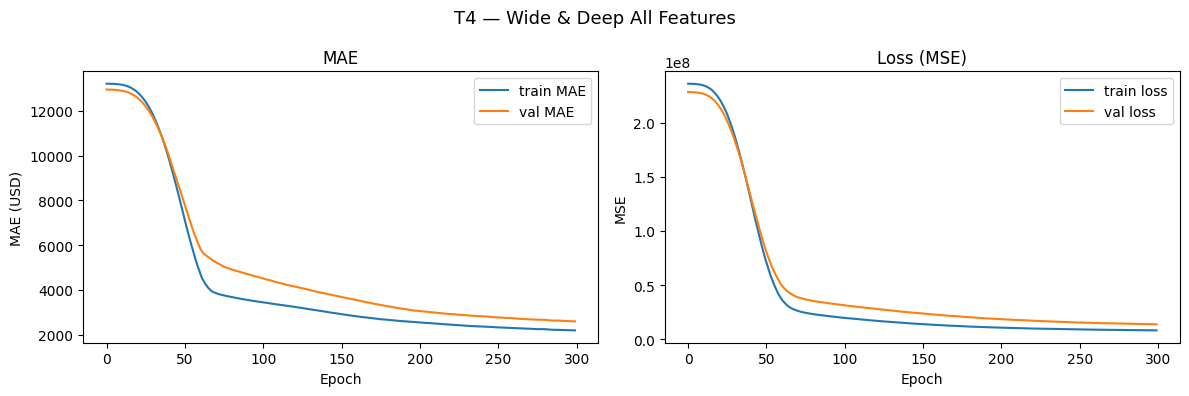

In [41]:
# T4.4 — Wide & Deep (all features)
#
# Architecture (Mixed-input Wide & Deep):
#   Numeric input (15) → Z-score norm already applied → Deep DNN path
#   Categorical input (n_oh one-hot dims) → Wide linear path
#   Combined output: wide + deep
#
# This mirrors the original DNNLinearCombinedRegressor intent:
#   - Linear path memorises brand/category-level price signals
#   - DNN path learns numeric feature combinations

tf.random.set_seed(SEED)

num_inp = keras.Input(shape=(len(numeric_feature_names),), name='numeric')
cat_inp = keras.Input(shape=(n_oh,), name='categorical')

# Wide: all features (numeric already z-scored, cat already one-hot)
all_concat = layers.Concatenate(name='all_features')([num_inp, cat_inp])
wide = layers.Dense(1, name='wide')(all_concat)

# Deep: numeric only → DNN
deep = layers.Dense(128, activation='relu', name='deep_1')(num_inp)
deep = layers.Dense(64,  activation='relu', name='deep_2')(deep)
deep = layers.Dense(1,   name='deep_out')(deep)

output = layers.Add(name='wide_deep')([wide, deep])
wd_all = keras.Model(inputs=[num_inp, cat_inp], outputs=output, name='T4_WideDeep_All')

wd_all.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
wd_all.summary()

hist_wd_all = wd_all.fit(
    [Xtr_zs, Xtr_cat_oh], ytr,
    validation_data=([Xva_zs, Xva_cat_oh], yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES], verbose=0
)

preds_wd_all = wd_all.predict([Xte_zs, Xte_cat_oh], verbose=0).flatten()
record('T4 Wide & Deep (all)', yte, preds_wd_all)
plot_learning_curves(hist_wd_all, 'T4 — Wide & Deep All Features')

---
## Final Summary — Cross-Task Comparison


── Full Results Table (sorted by RMSE) ──
                               mae     rmse
T4 RandomForest (all)       $1,902   $2,777
T3 MLP + One-Hot            $1,773   $2,812
T1 RandomForest             $2,000   $2,873
T2 RandomForest + Z-score   $2,007   $2,875
T4 MLP [128,64] (all)       $2,202   $3,235
T3 RandomForest + One-Hot   $2,515   $3,913
T4 Wide & Deep (all)        $2,647   $4,223
T3 RandomForest + Ordinal   $2,900   $4,587
T1 MLP [64]                 $3,108   $5,299
T1 MLP [64, 32]             $2,952   $5,338
T1 MLP [128, 64]            $3,078   $5,500
T1 Wide & Deep              $3,273   $5,873
T3 MLP + Ordinal            $4,178   $6,971
T1 Linear                   $4,729   $8,105
T2 MLP + Min-Max           $10,633  $13,299
T2 MLP + Z-score           $11,878  $14,109
T3 Linear + Ordinal        $12,870  $15,290
T4 Linear (all)            $13,208  $15,546
T3 Linear + One-Hot        $13,215  $15,595


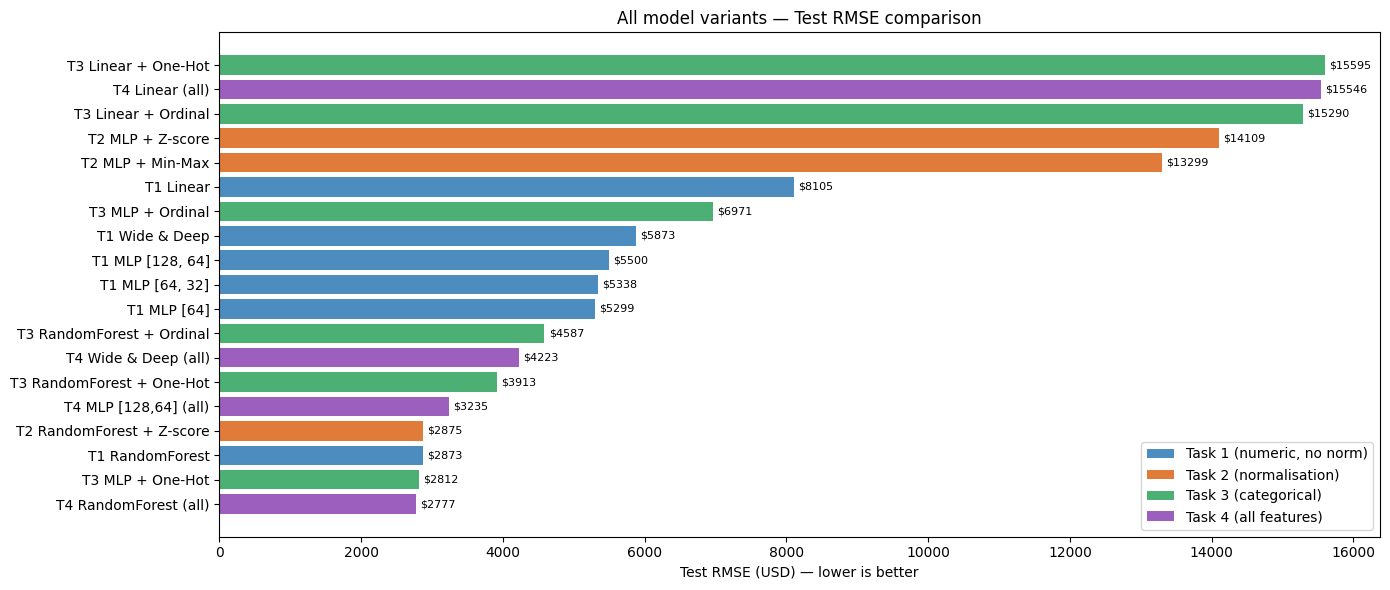


Best model: T4 RandomForest (all)  —  RMSE $2,777


In [ ]:
# Finally, I'm compiling all results into a summary DataFrame 
# and plotting a bar chart of RMSE for all model variants to visually compare their performance.

# Thanks for the challenge, it's been a great exercise in careful experimentation and analysis!

summary = pd.DataFrame(results).T.sort_values('rmse')
summary['mae']  = summary['mae'].apply(lambda x: f'${x:,.0f}')
summary['rmse'] = summary['rmse'].apply(lambda x: f'${x:,.0f}')
print('\n── Full Results Table (sorted by RMSE) ──')
print(summary.to_string())

# Bar chart — RMSE for all variants
rmse_vals = {k: v['rmse'] for k, v in results.items()}
sorted_keys = sorted(rmse_vals, key=rmse_vals.get)
sorted_rmse = [rmse_vals[k] for k in sorted_keys]

colours = []
for k in sorted_keys:
    if k.startswith('T1'): colours.append('#4c8cbf')
    elif k.startswith('T2'): colours.append('#e07b39')
    elif k.startswith('T3'): colours.append('#4caf73')
    else: colours.append('#9c5fbd')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(sorted_keys, sorted_rmse, color=colours)
ax.set_xlabel('Test RMSE (USD) — lower is better')
ax.set_title('All model variants — Test RMSE comparison')
ax.bar_label(bars, fmt='$%.0f', padding=3, fontsize=8)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#4c8cbf', label='Task 1 (numeric, no norm)'),
    Patch(facecolor='#e07b39', label='Task 2 (normalisation)'),
    Patch(facecolor='#4caf73', label='Task 3 (categorical)'),
    Patch(facecolor='#9c5fbd', label='Task 4 (all features)'),
]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.show()

# Best model
best = sorted_keys[0]
print(f'\nBest model: {best}  —  RMSE ${rmse_vals[best]:,.0f}')